In [ ]:
# Code part 1 to solve Weak Text Representation (TF-IDF)
# First, install the sentence-transformers library
!pip install -q sentence-transformers
from sentence_transformers import SentenceTransformer
import numpy as np

In [ ]:
import pandas as pd

datapro = pd.read_csv("/content/data_cv.csv", sep=';')
print(datapro.shape) # Show rows and columns count
print(datapro.columns)# Show column names
print("---------------------")
print(datapro.isnull().sum())


(2876, 5)
Index(['resume_id', 'category', 'resume_text', 'skills_list',
       'experience_years'],
      dtype='object')
---------------------
resume_id           20
category            20
resume_text         41
skills_list         43
experience_years    58
dtype: int64


In [ ]:
# Drop rows with any missing values in any column
datapro = datapro.dropna()  # Remove rows with NaN in any column

# Keep only rows where experience_years is between 0 and 50
datapro = datapro[(datapro['experience_years'] >= 0) & (datapro['experience_years'] <= 50)]

# Check the result
print(datapro.shape)                     # Show number of rows and columns after cleaning
print(datapro['experience_years'].describe())  # Statistical summary of experience_years

datapro.to_csv("cleaned_data.csv", index=False, sep=';')

(2770, 5)
count    2770.000000
mean        3.693141
std         7.271875
min         0.000000
25%         0.000000
50%         0.000000
75%         4.000000
max        50.000000
Name: experience_years, dtype: float64


In [ ]:
# Check counts
print(datapro['category'].value_counts())


category
HR                                    118
INFORMATION-TECHNOLOGY                118
BUSINESS-DEVELOPMENT                  117
ACCOUNTANT                            116
ADVOCATE                              115
FITNESS                               115
FINANCE                               115
ENGINEERING                           114
AVIATION                              114
HEALTHCARE                            113
CHEF                                  113
SALES                                 113
BANKING                               112
CONSULTANT                            112
PUBLIC-RELATIONS                      109
CONSTRUCTION                          107
DESIGNER                              105
TEACHER                               100
ARTS                                   98
APPAREL                                94
DIGITAL-MEDIA                          94
AGRICULTURE                            60
AUTOMOBILE                             35
Full Stack Developer     

In [ ]:
import nltk
nltk.download('punkt_tab')
nltk.download('punkt')       # Tokenizer models
nltk.download('stopwords')   # Common stopwords
nltk.download('wordnet')     # WordNet for lemmatization
nltk.download('omw-1.4')     # WordNet data


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [ ]:
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_lemmatize_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    words = word_tokenize(text)
    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]
    return " ".join(words)

datapro['clean_resume'] = datapro['resume_text'].apply(clean_lemmatize_text)


In [ ]:

# Load a pre-trained SBERT model
model = SentenceTransformer('all-MiniLM-L6-v2')

# Encode each cleaned CV into a dense vector (embedding)
embeddings = model.encode(datapro['clean_resume'].tolist(), batch_size=32, show_progress_bar=True)

# Convert the list of embeddings to a numpy array
X_sbert = np.array(embeddings)
print("SBERT embeddings shape:", X_sbert.shape)  # Shape: (number of CVs, embedding dimension)


Batches:   0%|          | 0/174 [00:00<?, ?it/s]

SBERT embeddings shape: (2770, 384)


In [ ]:
from sklearn.preprocessing import LabelEncoder

# Encode category labels
le = LabelEncoder()
y = le.fit_transform(datapro['category'])

print("Encoded classes:", le.classes_)
print("First 10 labels:", y[:10])



Encoded classes: ['ACCOUNTANT' 'ADVOCATE' 'AGRICULTURE' 'APPAREL' 'ARTS' 'AUTOMOBILE'
 'AVIATION' 'Advocate' 'Arts' 'Automation Testing' 'BANKING' 'BPO'
 'BUSINESS-DEVELOPMENT' 'Backend Developer' 'Blockchain'
 'Business Analyst' 'CHEF' 'CONSTRUCTION' 'CONSULTANT' 'Civil Engineer'
 'Cloud Engineer' 'DESIGNER' 'DIGITAL-MEDIA' 'Data Science'
 'Data Scientist' 'Database' 'DevOps Engineer' 'DotNet Developer'
 'ENGINEERING' 'ETL Developer' 'Electrical Engineering' 'FINANCE'
 'FITNESS' 'Frontend Developer' 'Full Stack Developer' 'HEALTHCARE' 'HR'
 'Hadoop' 'Health and fitness' 'INFORMATION-TECHNOLOGY' 'Java Developer'
 'Machine Learning Engineer' 'Mechanical Engineer'
 'Mobile App Developer (iOS/Android)' 'Network Security Engineer'
 'Operations Manager' 'PMO' 'PUBLIC-RELATIONS' 'Python Developer' 'SALES'
 'SAP Developer' 'Sales' 'TEACHER' 'Testing' 'Web Designing']
First 10 labels: [36 36 36 36 36 36 36 36 36 36]


In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

# Split data first
X_train, X_test, y_train, y_test = train_test_split(
    X_sbert, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Original train shape:", X_train.shape)
print("Resampled train shape:", X_train_res.shape)

Original train shape: (2216, 384)
Resampled train shape: (5225, 384)


In [ ]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(
    max_iter=3000,
    class_weight='balanced',
    n_jobs=-1,
    multi_class='ovr'
)

log_model.fit(X_train, y_train)
y_pred = log_model.predict(X_test)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Accuracy
acc = accuracy_score(y_test, y_pred)

# Precision / Recall / F1 (macro-average for multi-class)
prec = precision_score(y_test, y_pred, average='macro')
rec  = recall_score(y_test, y_pred, average='macro')
f1   = f1_score(y_test, y_pred, average='macro')

# ROC-AUC (One-vs-Rest)
y_prob = log_model.predict_proba(X_test)
roc = roc_auc_score(y_test, y_prob, multi_class='ovr')

print("Accuracy :", acc)
print("Precision:", prec)
print("Recall   :", rec)
print("F1-Score :", f1)
print("ROC-AUC  :", roc)


Accuracy : 0.7292418772563177
Precision: 0.6701677786656749
Recall   : 0.6813455485641883
F1-Score : 0.6662827262613288
ROC-AUC  : 0.9716650726782862


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


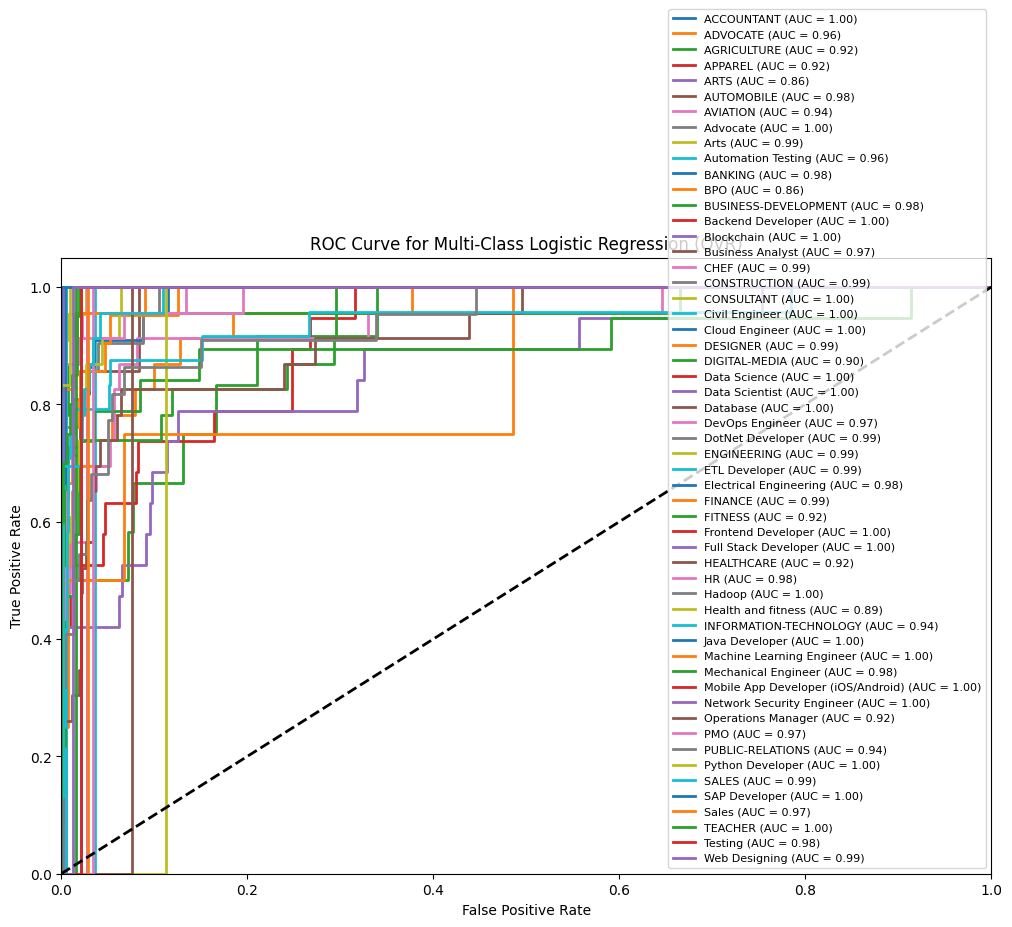

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import numpy as np

# Binarize y_test (needed for multi-class ROC)
y_test_bin = label_binarize(y_test, classes=np.arange(len(le.classes_)))
n_classes = y_test_bin.shape[1]

# Get predicted probabilities
y_score = log_model.predict_proba(X_test)

# Plot ROC curve for each class
plt.figure(figsize=(12, 8))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{le.classes_[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)  # diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Multi-Class Logistic Regression (OVR)')
plt.legend(loc='lower right', fontsize=8)
plt.show()


In [1]:
# code part 2 to measure bias and fairness
!pip install fairlearn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 29.5 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.3
    Uninstalling scipy-1.16.3:
      Successfully uninstalled scipy-1.16.3


In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score
)
from fairlearn.metrics import (
    demographic_parity_difference,
    demographic_parity_ratio,
    equalized_odds_difference,
    MetricFrame
)
from fairlearn.reductions import ExponentiatedGradient, EqualizedOdds
import matplotlib.pyplot as plt


# 1) Load + Basic Preparation
# Load the CSV file which has a single messy column separated by semicolons
df_raw = pd.read_csv("data_cv.csv")
# Identify the first column which contains all fields joined together
first_column_name = df_raw.columns[0]

# Split this column into separate fields: resume_id, category, resume_text, skills, experience.
df_split = df_raw[first_column_name].str.split(';', n=4, expand=True)
df_split.columns = ['resume_id', 'category', 'resume_text', 'skills_list', 'experience_years']
# Copy the cleaned dataframe.
df = df_split.copy()
# Convert experience_years into numeric type (turn invalid values into NaN)
df['experience_years'] = pd.to_numeric(df['experience_years'], errors='coerce')

# Making sure that key columns exist after processing
assert "resume_text" in df.columns
assert "category" in df.columns
assert "experience_years" in df.columns
# Remove rows where important values are missing.
df = df.dropna(subset=["resume_text", "category", "experience_years"])
# Create a sensitive attribute (experience group) based on experience years.
# This will be used later for fairness evaluation.
df["exp_group"] = pd.cut(
    df["experience_years"],
    bins=[-1, 2, 5, 100],   # 0–2 = junior, 3–5 = mid, 6+ = senior
    labels=["junior", "mid", "senior"]
)

# Remove rows where exp_group failed to generate.
df = df.dropna(subset=["exp_group"])


In [4]:
# 2) Build a Binary Label
# Choose the specific job category we want to test fairness on.
TARGET_CLASS = "HR"

# If the dataset does not contain the target class, stop execution.
if TARGET_CLASS not in df["category"].unique():
    print("TARGET_CLASS not in dataset categories. Available:", df["category"].unique())
    raise SystemExit()
# Create a binary label: 1 = target class, 0 = all other classes.
df["y_binary"] = (df["category"] == TARGET_CLASS).astype(int)
# Features (text), labels, and sensitive groups.
X_text = df["resume_text"]
y_bin = df["y_binary"]
sensitive = df["exp_group"]

# 3) TF-IDF Vectorization
# Transform raw text into numerical features using TF-IDF (unigrams + bigrams).
vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=8000,
    ngram_range=(1,2)
)
X = vectorizer.fit_transform(X_text)

# 4) Train/Test Split
# Spliting the data while preserving class balance using stratification. Testing is 20%
X_train, X_test, y_train, y_test, s_train, s_test = train_test_split(
    X, y_bin, sensitive,
    test_size=0.2,
    random_state=42,
    stratify=y_bin
)
# Convert labels into integers to avoid issues with Fairlearn.
y_train = y_train.values.astype(int)
y_test = y_test.values.astype(int)


In [5]:
# 5) BASELINE SVM Model
# Build a simple SVM classifier without any fairness constraints.
clf_svm = LinearSVC(class_weight="balanced")
clf_svm.fit(X_train, y_train)
y_pred_svm = clf_svm.predict(X_test)

# Performance evaluation of the baseline model.
acc  = accuracy_score(y_test, y_pred_svm)
prec = precision_score(y_test, y_pred_svm)
rec  = recall_score(y_test, y_pred_svm)
f1   = f1_score(y_test, y_pred_svm)
print("\n--- Baseline SVM Performance ---")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-score:  {f1:.4f}")

# Fairness metrics for the SVM model
dpd_svm = demographic_parity_difference(y_test, y_pred_svm, sensitive_features=s_test)
dpr_svm = demographic_parity_ratio(y_test, y_pred_svm, sensitive_features=s_test)
eod_svm = equalized_odds_difference(y_test, y_pred_svm, sensitive_features=s_test)
print("\n--- Baseline SVM fairness ---")
print(f"Demographic Parity Difference : {dpd_svm:.4f}")
print(f"Demographic Parity Ratio      : {dpr_svm:.4f}")
print(f"Equalized Odds Difference     : {eod_svm:.4f}")

# Group-wise (junior, mid, senior) performance
mf_svm = MetricFrame(
    metrics={
        "accuracy": accuracy_score,
        "recall": recall_score,
        "precision": precision_score,
        "f1": f1_score
    },
    y_true=y_test,
    y_pred=y_pred_svm,
    sensitive_features=s_test
)
print("\nGroup-wise metrics (SVM):")
print(mf_svm.by_group)



--- Baseline SVM Performance ---
Accuracy:  0.9856
Precision: 0.8077
Recall:    0.8750
F1-score:  0.8400

--- Baseline SVM fairness ---
Demographic Parity Difference : 0.0110
Demographic Parity Ratio      : 0.8011
Equalized Odds Difference     : 0.1667

Group-wise metrics (SVM):
           accuracy    recall  precision        f1
exp_group                                         
junior     0.987013  0.833333   0.882353  0.857143
mid        1.000000  1.000000   1.000000  1.000000
senior     0.976378  1.000000   0.571429  0.727273


In [6]:
# 6) FAIR MODEL ExponentiatedGradient + Logistic Regression model (Equalized Odds)
# We use ExponentiatedGradient on Logistic Regression because it works well
# with fairness constraints such as Equalized Odds.
base_lr = LogisticRegression(max_iter=2000, class_weight="balanced")

# Define the fairness constraint: equalize True Positive / False Positive rates.
constraint = EqualizedOdds()
# Build the fairness-aware classifier.
fair_clf = ExponentiatedGradient(
    estimator=base_lr,
    constraints=constraint
)
# Fairlearn requires dense representation.
fair_clf.fit(X_train.toarray(), y_train, sensitive_features=s_train)
y_pred_fair = fair_clf.predict(X_test.toarray())

# Evaluate performance for the fair model.
acc_f  = accuracy_score(y_test, y_pred_fair)
prec_f = precision_score(y_test, y_pred_fair)
rec_f  = recall_score(y_test, y_pred_fair)
f1_f   = f1_score(y_test, y_pred_fair)
print("\n--- Fair Model (EG + LR) performance ---")
print(f"Accuracy:  {acc_f:.4f}")
print(f"Precision: {prec_f:.4f}")
print(f"Recall:    {rec_f:.4f}")
print(f"F1-score:  {f1_f:.4f}")

# Fairness metrics for the fair model.
dpd_f = demographic_parity_difference(y_test, y_pred_fair, sensitive_features=s_test)
dpr_f = demographic_parity_ratio(y_test, y_pred_fair, sensitive_features=s_test)
eod_f = equalized_odds_difference(y_test, y_pred_fair, sensitive_features=s_test)
print("\n--- Fair Model (EG + LR) Fairness ---")
print(f"Demographic Parity Difference : {dpd_f:.4f}")
print(f"Demographic Parity Ratio      : {dpr_f:.4f}")
print(f"Equalized Odds Difference     : {eod_f:.4f}")

# Group-wise performance for fair model.
mf_fair = MetricFrame(
    metrics={
        "accuracy": accuracy_score,
        "recall": recall_score,
        "precision": precision_score,
        "f1": f1_score
    },
    y_true=y_test,
    y_pred=y_pred_fair,
    sensitive_features=s_test
)
print("\nGroup-wise metrics (EG + LR):")
print(mf_fair.by_group)



--- Fair Model (EG + LR) performance ---
Accuracy:  0.9856
Precision: 0.7667
Recall:    0.9583
F1-score:  0.8519

--- Fair Model (EG + LR) Fairness ---
Demographic Parity Difference : 0.0097
Demographic Parity Ratio      : 0.8247
Equalized Odds Difference     : 0.0556

Group-wise metrics (EG + LR):
           accuracy    recall  precision        f1
exp_group                                         
junior     0.987013  0.944444   0.809524  0.871795
mid        1.000000  1.000000   1.000000  1.000000
senior     0.976378  1.000000   0.571429  0.727273


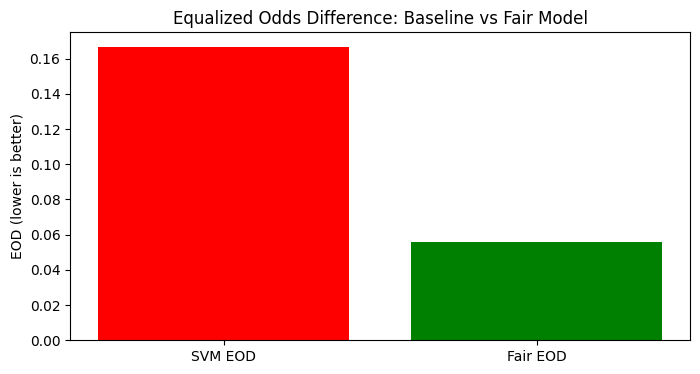

In [7]:
# 7) Visualization: Before vs After Fairness
plt.figure(figsize=(8,4))
plt.bar(["SVM EOD", "Fair EOD"], [eod_svm, eod_f], color=["red","green"])
plt.title("Equalized Odds Difference: Baseline vs Fair Model")
plt.ylabel("EOD (lower is better)")
plt.show()